In [11]:
# Importing the required libraries-:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
# Loading the dataset
df = pd.read_excel("C:/Users/ayush/Downloads/Online Retail.xlsx")


In [13]:
# Exploring the dataset and its data types
df.info()
df.head(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [14]:
# Descriptive analysis for data distribution and to detect outliers
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


<Axes: xlabel='Quantity'>

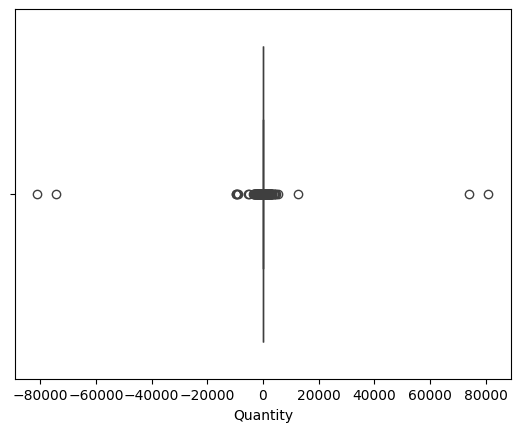

In [15]:
# Identifying outliers in the transection amount 
df['Quantity'].describe()
sns.boxplot(x=df['Quantity'])


<Axes: xlabel='UnitPrice'>

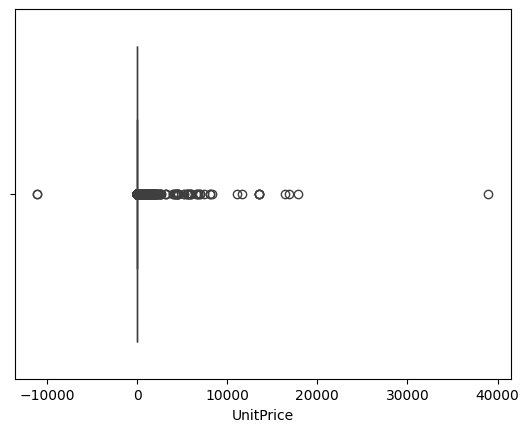

In [16]:
# Identifying outliers in per unit price 
df['UnitPrice'].describe()
sns.boxplot(x=df['UnitPrice'])

In [17]:
# Null value count per column
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [18]:
# Percentage of null values identifying which column should be removed 
missing_percent = df.isnull().sum()/len(df)*100
missing_percent.sort_values(ascending=False)


CustomerID     24.926694
Description     0.268311
StockCode       0.000000
InvoiceNo       0.000000
Quantity        0.000000
InvoiceDate     0.000000
UnitPrice       0.000000
Country         0.000000
dtype: float64

In [19]:
# Removing CustomerID (Percentage Count-: 24.926694%)
df = df.dropna(subset=['CustomerID'])

# Replacing NULLS with "Unknown Product" 
df['Description'] = df['Description'].fillna('Unknown Product')

# Removing duplicate rows.
df = df.drop_duplicates()

# Removing transection where Quantity and UnitPrice is 0.
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

# Correcting Datatypes.
df['CustomerID'] = df['CustomerID'].astype(int)
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], errors='coerce')

# Removing NULLS in InvoiceDate
df = df.dropna(subset=['InvoiceDate'])

In [20]:
# Creating new numeric feature.
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

print("\nColumns before encoding:", df.columns.tolist())

if 'Country' in df.columns:
    df = pd.get_dummies(df, columns=['Country'])
    print("Country column encoded")
else:
    print("Country column already encoded or missing")


# Standardize numeric features.
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df[['Quantity','UnitPrice','TotalPrice']] = scaler.fit_transform(
    df[['Quantity','UnitPrice','TotalPrice']]
)


Columns before encoding: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country', 'TotalPrice']
Country column encoded


In [21]:
# Creating single datetime feature.
df['DateTime_Feature'] = df['InvoiceDate'].astype('int64') // 10**9


# Removing non-ML columns.
columns_to_drop = ['InvoiceNo','StockCode','Description','InvoiceDate']
df_ml = df.drop([col for col in columns_to_drop if col in df.columns], axis=1)

In [22]:
# Printing the final dataset(Preview).
print("\nFINAL DATASET PREVIEW")
print(df_ml.head())

print("\nFINAL INFO")
print(df_ml.info())



FINAL DATASET PREVIEW
   Quantity  UnitPrice  CustomerID  TotalPrice  Country_Australia  \
0 -0.039446  -0.025893       17850   -0.023566              False   
1 -0.039446   0.011873       17850   -0.007366              False   
2 -0.028365  -0.016901       17850   -0.002030              False   
3 -0.039446   0.011873       17850   -0.007366              False   
4 -0.039446   0.011873       17850   -0.007366              False   

   Country_Austria  Country_Bahrain  Country_Belgium  Country_Brazil  \
0            False            False            False           False   
1            False            False            False           False   
2            False            False            False           False   
3            False            False            False           False   
4            False            False            False           False   

   Country_Canada  ...  Country_Saudi Arabia  Country_Singapore  \
0           False  ...                 False              Fals